In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("D:\CSV files\insurance.csv")

In [5]:
df.head()

,age,affordibility,insurance
0,21,1,0
1,25,1,0
2,31,0,0
3,50,1,1
4,41,1,1


In [6]:
df.drop("insurance",axis=1,inplace=True)

In [7]:
df.head()

,age,affordibility
0,21,1
1,25,1
2,31,0
3,50,1
4,41,1


In [8]:
df.shape

(34, 2)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            34 non-null     int64
 1   affordibility  34 non-null     int64
dtypes: int64(2)
memory usage: 676.0 bytes


In [10]:
df.isnull().sum()

age              0
affordibility    0
dtype: int64

In [11]:
df.describe()

,age,affordibility
count,34.000000,34.000000
mean,35.911765,0.558824
std,13.369725,0.503995
min,17.000000,0.000000
25%,25.000000,0.000000
50%,34.500000,1.000000
75%,44.000000,1.000000
max,61.000000,1.000000


In [12]:
df.head()

,age,affordibility
0,21,1
1,25,1
2,31,0
3,50,1
4,41,1


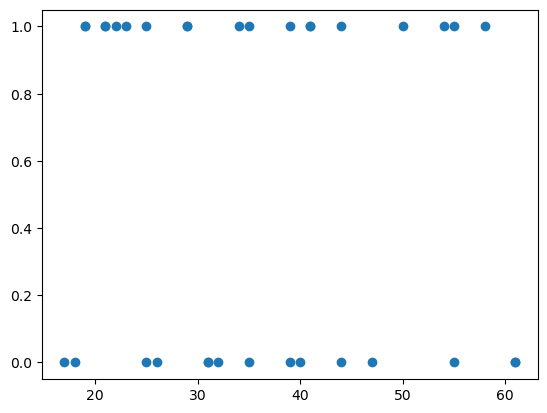

In [13]:
plt.scatter(df["age"],df['affordibility'])

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
scaler = MinMaxScaler()

In [16]:
df[['age']] = scaler.fit_transform(df[['age']])

In [17]:
df[['affordibility']] = scaler.fit_transform(df[['affordibility']])

In [18]:
from sklearn.cluster import KMeans

In [35]:
model = KMeans(n_clusters=2)
model.fit(df[["age","affordibility"]])

KMeans(n_clusters=2)

In [36]:
model.predict(df[["age","affordibility"]])

array([0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0], dtype=int32)

In [37]:
df["clusters"] = model.predict(df[["age","affordibility"]])
df.head()

,age,affordibility,clusters
0,0.090909,1.0,0
1,0.181818,1.0,0
2,0.318182,0.0,1
3,0.750000,1.0,0
4,0.545455,1.0,0


In [40]:
df0 = df[df["clusters"]==0]
df1 = df[df["clusters"]==1]
# df2 = df[df["clusters"]==2]

In [41]:
df0

,age,affordibility,clusters
0,0.090909,1.0,0
1,0.181818,1.0,0
3,0.750000,1.0,0
4,0.545455,1.0,0
5,0.409091,1.0,0
8,0.045455,1.0,0
9,0.136364,1.0,0
10,0.113636,1.0,0
11,0.545455,1.0,0
14,0.863636,1.0,0


In [42]:
df1

,age,affordibility,clusters
2,0.318182,0.0,1
6,1.000000,0.0,1
7,0.863636,0.0,1
12,0.613636,0.0,1
13,1.000000,0.0,1
16,0.318182,0.0,1
20,0.681818,0.0,1
21,0.500000,0.0,1
26,0.204545,0.0,1
27,0.522727,0.0,1


In [43]:
df2

,age,affordibility,clusters


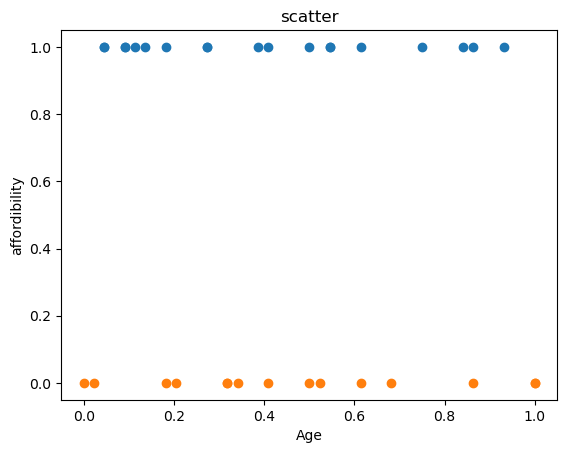

In [45]:
plt.scatter(df0["age"],df0["affordibility"])
plt.scatter(df1["age"],df1["affordibility"])
# plt.scatter(df2["age"],df2["affordibility"])
plt.xlabel("Age")
plt.ylabel("affordibility")
plt.title('scatter')
plt.show()

In [46]:
model.cluster_centers_

array([[4.01913876e-01, 1.00000000e+00],
       [4.65151515e-01, 1.11022302e-16]])

In [47]:
model.cluster_centers_[:,0]

array([0.40191388, 0.46515152])

In [48]:
model.cluster_centers_[:,1]

array([1.00000000e+00, 1.11022302e-16])

In [49]:
model.inertia_

3.0133463824851385

In [50]:
sse = []
krange = range(1,10)
for i in krange:
    model = KMeans(n_clusters=i)
    model.fit(df[["age", "affordibility"]])
    sse.append(model.inertia_)

In [51]:
krange

range(1, 10)

In [52]:
sse

[11.42922034516286,
 3.0133463824851385,
 2.0199868537562913,
 0.8016659362217212,
 0.5486715777908959,
 0.2918736881805063,
 0.23005829397874852,
 0.12472328807556078,
 0.1086002066115702]

Text(0.5, 1.0, 'Scatter')

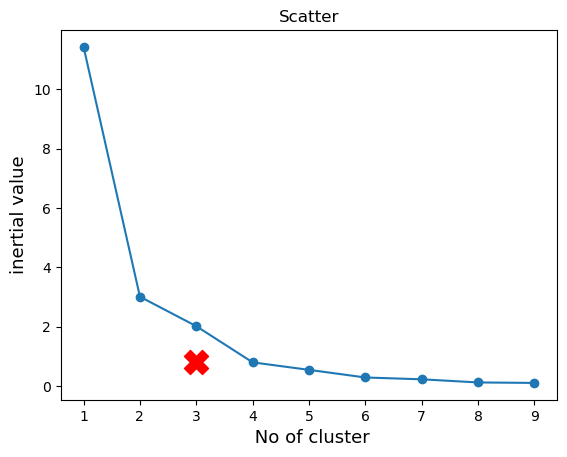

In [53]:
plt.plot(krange, sse)
plt.scatter(krange, sse)
plt.scatter(3, sse[3], marker="X",s=300, c="r")
plt.xlabel(" No of cluster", size=13) 
plt.ylabel("inertial value", size=13)
plt.title("Scatter")